## **Autoencoder**

**An Autoencoder** is a type of artificial neural network used primarily for learning efficient codings of unlabeled data, typically through unsupervised learning.

**Its primary goal** is to compress input data into a compact, meaningful representation (called encoding or latent space) and then reconstruct the original data as closely as possible from this compressed form.

**Key components of an autoencoder include:**

**1. Encoder:** Compresses the input data by reducing its dimensionality, extracting the essential features.

**2. Bottleneck (Latent Space)**: The compressed representation containing the most important information in a reduced dimension.

**3. Decoder:** Reconstructs the input data from the compressed representation, aiming to replicate the original data.

**4. Autoencoders** are useful for tasks like dimensionality reduction, feature extraction, denoising, anomaly detection, and even generating new data in certain variants (such as variational autoencoders).

AEs have evolved into denoising autoencoders, sparse autoencoders, contractive autoencoders, variational autoencoders (VAEs), and adversarial autoencoders (AAEs)

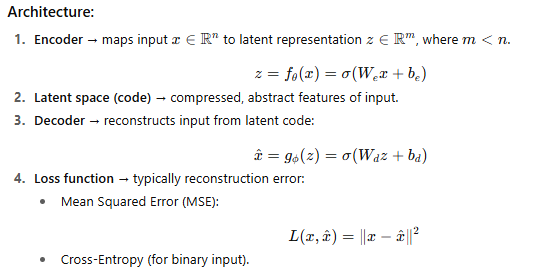

**Key Intuitions about Autoencoders**

A. Unlike PCA, AEs *can capture nonlinear structure of data.*

B. Encoder learns low-dimensional features (like edges, textures, shapes).

C. Decoder ensures features preserve enough info to reconstruct original input.

D. When trained on CIFAR-10, the encoder learns basic image features like edges, corners, blobs (similar to CNN filters).

**Variants of Autoencoders**

For CIFAR-10, these variants are particularly interesting:

A. Denoising Autoencoders (DAE) → Learn robust features by reconstructing images from corrupted input.

B. Convolutional Autoencoders (CAE) → Use CNNs for better image feature extraction.

C. Sparse Autoencoders → Encourage sparsity in latent representation → useful for interpretability.

D. Contractive Autoencoders → Add penalty to encourage stability in latent space.


**Datasets: Autoencoder Training on CIFAR-10**

Input: 32×32×3 images (RGB).

Encoder: CNN layers reduce dimensions (Conv → Pool → Dense).

Latent vector: size ~ 64–256 (tunable).

Decoder: CNN transpose / upsampling layers reconstruct back to 32×32×3.

Loss: MSE or Binary Cross-Entropy.

Optimizer: Adam (LR ~ 1e-3).

**Autoencoders on CIFAR-10:**

CIFAR-10 has natural images (airplanes, cars, animals, etc.), so we can evaluate how well AEs learn semantic structure.

Useful for tasks like:

Image Denoising

Anomaly Detection (train AE on certain classes, test reconstruction error on others)

Feature Extraction (latent vectors as input for classification tasks).

**Theoretical Challenges**

Information bottleneck: If latent space too small → underfitting, too large → identity mapping.

Blurred reconstructions: Pixel-wise MSE loss → tends to produce smooth, blurry images.

Not truly generative: AEs don’t model probability distribution like VAEs or GANs.

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
cifar10_autoencoder_tutorial.py

A from-scratch, step-by-step tutorial script for training a Convolutional
Autoencoder (AE) on CIFAR-10 with verbose prints that explain each step.

What you'll learn (and see printed out):
1) What an Autoencoder is and what problem it's solving on CIFAR-10 images.
2) How the Encoder compresses 32x32x3 images into a small latent vector (the "bottleneck").
3) How the Decoder reconstructs images from that latent vector.
4) Why we use MSE reconstruction loss and what gradient descent is doing to minimize it.
5) How to optionally train a "Denoising Autoencoder" by corrupting inputs and reconstructing the clean target.
6) Evaluation: test-set reconstruction loss and PSNR, plus saved grids of originals vs reconstructions.

Usage (CPU or GPU):
    python cifar10_autoencoder_tutorial.py --epochs 10 --latent-dim 128 --batch-size 128
Optional denoising mode:
    python cifar10_autoencoder_tutorial.py --denoise --noise-std 0.2
"""

import os
import math
import time
import argparse
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image

# ---------------------------
# 0) Utilities
# ---------------------------

def seed_everything(seed: int = 42):
    print(f"[Setup] Seeding everything with seed={seed} for reproducibility.")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinism can reduce speed, but makes runs more repeatable.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def human_bytes(num_params: int) -> str:
    # Just a neat helper to pretty-print parameter counts
    return f"{num_params:,}"

def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_grid(tensor, path, nrow=8, normalize=True):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    grid = make_grid(tensor, nrow=nrow, normalize=normalize)
    save_image(grid, path)
    print(f"[Save] Wrote image grid to: {path}")

# ---------------------------
# 1) Model: Convolutional Autoencoder
# ---------------------------

class ConvAutoencoder(nn.Module):
    """
    A simple Convolutional Autoencoder for 32x32x3 images:
    - Encoder progressively halves spatial dims (32->16->8->4) while increasing channels.
    - Latent (bottleneck) is a small vector (e.g., 128 dims).
    - Decoder mirrors the process to reconstruct the image back to 32x32x3.

    We print shapes on the *first* forward pass when explain_shapes=True
    to make the bottleneck explicit without spamming the console during training.
    """
    def __init__(self, latent_dim=128, explain_shapes=False):
        super().__init__()
        self.explain_shapes_once = explain_shapes

        # Encoder: input (B, 3, 32, 32)
        self.enc_conv1 = nn.Conv2d(3,   32, kernel_size=3, stride=2, padding=1)  # -> (B, 32, 16, 16)
        self.enc_conv2 = nn.Conv2d(32,  64, kernel_size=3, stride=2, padding=1)  # -> (B, 64,  8,  8)
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)  # -> (B,128,  4,  4)
        self.enc_act = nn.ReLU(inplace=True)
        self.enc_flatten = nn.Flatten()
        self.enc_fc = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder:
        self.dec_fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.dec_unflatten = nn.Unflatten(1, (128, 4, 4))
        self.dec_deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)  # -> (B,64,  8,  8)
        self.dec_deconv2 = nn.ConvTranspose2d(64,  32, kernel_size=3, stride=2, padding=1, output_padding=1)  # -> (B,32, 16, 16)
        self.dec_deconv3 = nn.ConvTranspose2d(32,   3, kernel_size=3, stride=2, padding=1, output_padding=1)  # -> (B,3,  32, 32)
        self.dec_act = nn.ReLU(inplace=True)
        self.dec_out = nn.Sigmoid()  # keep outputs in [0,1] to match ToTensor()

    def encode(self, x):
        if self.explain_shapes_once:
            print(f"[Encode] Input shape: {tuple(x.shape)} (B,C,H,W) expected (B,3,32,32)")
        x = self.enc_act(self.enc_conv1(x))
        if self.explain_shapes_once:
            print(f"[Encode] After conv1 -> {tuple(x.shape)} (downsample 32->16)")
        x = self.enc_act(self.enc_conv2(x))
        if self.explain_shapes_once:
            print(f"[Encode] After conv2 -> {tuple(x.shape)} (downsample 16->8)")
        x = self.enc_act(self.enc_conv3(x))
        if self.explain_shapes_once:
            print(f"[Encode] After conv3 -> {tuple(x.shape)} (downsample 8->4)")
        x = self.enc_flatten(x)
        if self.explain_shapes_once:
            print(f"[Encode] After flatten -> {tuple(x.shape)} (B, 128*4*4)")
        z = self.enc_fc(x)
        if self.explain_shapes_once:
            print(f"[Encode] Latent vector z shape: {tuple(z.shape)} (B, latent_dim)")
        return z

    def decode(self, z):
        if self.explain_shapes_once:
            print(f"[Decode] Latent input z shape: {tuple(z.shape)}")
        x = self.dec_fc(z)
        if self.explain_shapes_once:
            print(f"[Decode] After dec_fc -> {tuple(x.shape)} (B, 128*4*4)")
        x = self.dec_unflatten(x)
        if self.explain_shapes_once:
            print(f"[Decode] After unflatten -> {tuple(x.shape)} (B,128,4,4)")
        x = self.dec_act(self.dec_deconv1(x))
        if self.explain_shapes_once:
            print(f"[Decode] After deconv1 -> {tuple(x.shape)} (upsample 4->8)")
        x = self.dec_act(self.dec_deconv2(x))
        if self.explain_shapes_once:
            print(f"[Decode] After deconv2 -> {tuple(x.shape)} (upsample 8->16)")
        x = self.dec_out(self.dec_deconv3(x))
        if self.explain_shapes_once:
            print(f"[Decode] After deconv3+sigmoid -> {tuple(x.shape)} (upsample 16->32, pixels in [0,1])")
            print("[Decode] Done explaining shapes (will print only once).")
            self.explain_shapes_once = False
        return x

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

# ---------------------------
# 2) Training & Evaluation
# ---------------------------

def add_noise(x, noise_std):
    if noise_std <= 0:
        return x
    noise = torch.randn_like(x) * noise_std
    x_noisy = torch.clamp(x + noise, 0.0, 1.0)
    return x_noisy

@torch.no_grad()
def evaluate(model, loader, device):
    print("\n[Eval] Running evaluation on the test set (computing MSE and PSNR)...")
    model.eval()
    mse_loss = nn.MSELoss(reduction="sum")
    total_se = 0.0
    total_pixels = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        se = mse_loss(x_hat, x).item()
        total_se += se
        total_pixels += x.numel()
    mse = total_se / total_pixels
    psnr = 20.0 * math.log10(1.0) - 10.0 * math.log10(mse + 1e-12)  # MAX_I=1 (data in [0,1])
    print(f"[Eval] Mean Squared Error (per-pixel): {mse:.6f}")
    print(f"[Eval] PSNR (dB): {psnr:.3f}")
    return mse, psnr

def train(args):
    seed_everything(args.seed)

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
    print(f"[Setup] Using device: {device}")
    if device.type == "cuda":
        print(f"[Setup] CUDA is available. Training will use your GPU for speed.")

    # Explain the task
    print("\n=== STEP A: What are we optimizing? ===")
    print("We are training an Autoencoder to minimize reconstruction error between input image x and")
    print("its reconstruction x_hat = Decoder(Encoder(x)). We'll use Mean Squared Error (MSE) loss:")
    print("    L = ||x - x_hat||^2")
    print("Stochastic gradient descent (Adam) will adjust the encoder/decoder weights to reduce L.\n")

    # Data
    print("=== STEP B: Loading CIFAR-10 (train/test) and preparing DataLoaders ===")
    transform = transforms.ToTensor()  # yields tensors in [0,1]
    train_set = torchvision.datasets.CIFAR10(root=args.data_dir, train=True, download=True, transform=transform)
    test_set  = torchvision.datasets.CIFAR10(root=args.data_dir, train=False, download=True, transform=transform)

    print(f"[Data] Train samples: {len(train_set)}, Test samples: {len(test_set)}")
    train_loader = DataLoader(train_set, batch_size=args.batch_size, shuffle=True,  num_workers=2, pin_memory=(device.type == "cuda"))
    test_loader  = DataLoader(test_set,  batch_size=args.batch_size, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

    # Peek & save a grid of raw training images
    print("[Data] Saving a small grid of raw training images to ./runs/samples_raw.png")
    x0, _ = next(iter(train_loader))
    save_grid(x0[:32], "./runs/samples_raw.png", nrow=8, normalize=True)

    # Model
    print("\n=== STEP C: Building the Convolutional Autoencoder ===")
    model = ConvAutoencoder(latent_dim=args.latent_dim, explain_shapes=True).to(device)
    num_params = count_trainable_parameters(model)
    print(f"[Model] AE created with latent_dim={args.latent_dim}. Trainable parameters: {human_bytes(num_params)}")
    print("[Model] We'll show a one-time shape trace on the first batch to reveal the bottleneck.")

    # Loss & Optimizer
    print("\n=== STEP D: Choosing loss and optimizer ===")
    criterion = nn.MSELoss(reduction="mean")
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    print(f"[Train] Loss: MSE (per-pixel average). Optimizer: Adam with lr={args.lr}")

    if args.denoise:
        print(f"[Train] Denoising mode: ON (noise_std={args.noise_std}). We'll corrupt inputs but reconstruct the clean targets.")
    else:
        print("[Train] Denoising mode: OFF. We'll reconstruct the inputs directly.")

    # Training loop
    print("\n=== STEP E: Training begins ===")
    print("Each epoch will iterate over the training set in mini-batches.")
    print("For each batch: x -> Encoder -> z (bottleneck) -> Decoder -> x_hat,")
    print("then compute MSE(x, x_hat), backpropagate, and update weights via Adam.\n")

    os.makedirs("./runs", exist_ok=True)
    global_step = 0
    for epoch in range(1, args.epochs + 1):
        model.train()
        running_loss = 0.0
        t0 = time.time()
        print(f"\n[Epoch {epoch:02d}/{args.epochs}] -------------------------------")
        for bidx, (x, _) in enumerate(train_loader, start=1):
            x = x.to(device, non_blocking=True)
            # Optional corruption for denoising AE
            x_input = add_noise(x, args.noise_std) if args.denoise else x

            optimizer.zero_grad(set_to_none=True)
            x_hat = model(x_input)  # NOTE: prints shapes on first pass only
            loss = criterion(x_hat, x)  # target is the clean image
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            global_step += 1

            # Print a few informative updates
            if bidx == 1:
                if args.denoise:
                    print(f"[Batch {bidx}] First batch this epoch: showing that we feed 'noisy' x to the AE and compare to 'clean' x.")
                else:
                    print(f"[Batch {bidx}] First batch this epoch: we feed x to the AE and compare x_hat to x (plain reconstruction).")
                print(f"[Batch {bidx}] Current batch reconstruction MSE: {loss.item():.6f}")
            elif bidx % args.log_every == 0:
                print(f"[Batch {bidx}] Running avg MSE this epoch: {running_loss / bidx:.6f}")

        epoch_loss = running_loss / len(train_loader)
        dt = time.time() - t0
        print(f"[Epoch {epoch:02d}] Mean train MSE: {epoch_loss:.6f} | Epoch time: {dt:.1f}s")

        # Save a grid of reconstructions for visual tracking
        with torch.no_grad():
            x_vis = x0[:32].to(device)
            x_in_vis = add_noise(x_vis, args.noise_std) if args.denoise else x_vis
            x_hat_vis = model(x_in_vis)
            # Stack: top row inputs to model, bottom row reconstructions
            save_grid(torch.cat([x_in_vis.cpu(), x_hat_vis.cpu()], dim=0),
                      f"./runs/recon_epoch_{epoch:02d}.png", nrow=8, normalize=True)

        # Quick latent stats on a mini-batch
        with torch.no_grad():
            z_sample = model.encode(x_vis)
            z_mean = z_sample.mean(dim=0).mean().item()
            z_std = z_sample.std(dim=0).mean().item()
            print(f"[Epoch {epoch:02d}] Latent z quick stats (mean over batch dims): mean≈{z_mean:.4f}, std≈{z_std:.4f}")

    print("\n=== STEP F: Final evaluation on the test set ===")
    test_mse, test_psnr = evaluate(model, test_loader, device)

    # Save final example recon grid
    with torch.no_grad():
        x_eval, _ = next(iter(test_loader))
        x_eval = x_eval.to(device)
        x_in_eval = add_noise(x_eval, args.noise_std) if args.denoise else x_eval
        x_hat_eval = model(x_in_eval)
        save_grid(torch.cat([x_in_eval[:32].cpu(), x_hat_eval[:32].cpu()], dim=0),
                  "./runs/recon_test_final.png", nrow=8, normalize=True)

    print("\n=== STEP G: What did we learn? ===")
    print("* The Encoder learned to compress 32x32x3 images down to a small latent vector (the bottleneck).")
    print("* The Decoder learned to reconstruct images from that vector by minimizing pixel-wise MSE.")
    print("* If outputs look a bit 'blurry', that's normal for MSE-trained AEs (it averages across plausible details).")
    print("* Denoising AE (if enabled) encourages learning features robust to noise by predicting the clean target.")
    print(f"* Final Test MSE: {test_mse:.6f}, PSNR: {test_psnr:.3f} dB")
    print("\nNext ideas:")
    print("- Try different latent sizes (e.g., 32, 64, 256) to study the information bottleneck trade-off.")
    print("- Swap loss to L1 (MAE) and compare sharpness.")
    print("- Use features from the latent z for downstream classification.")
    print("- Move on to VAEs or GANs to get *generative* sampling beyond reconstruction.")

# ---------------------------
# 3) Argparse
# ---------------------------

def parse_args():
    import argparse
    parser = argparse.ArgumentParser(description="CIFAR-10 Autoencoder with verbose, step-by-step prints.")
    parser.add_argument("--data-dir", type=str, default="./data", help="Where to store/load CIFAR-10.")
    parser.add_argument("--epochs", type=int, default=5, help="Training epochs.")
    parser.add_argument("--batch-size", type=int, default=128, help="Mini-batch size.")
    parser.add_argument("--latent-dim", type=int, default=128, help="Bottleneck size.")
    parser.add_argument("--lr", type=float, default=1e-3, help="Adam learning rate.")
    parser.add_argument("--denoise", action="store_true", help="Enable denoising autoencoder training.")
    parser.add_argument("--noise-std", type=float, default=0.2, help="Std of Gaussian noise for denoising mode.")
    parser.add_argument("--cpu", action="store_true", help="Force CPU (ignore CUDA if available).")
    parser.add_argument("--seed", type=int, default=42, help="Random seed.")
    parser.add_argument("--log-every", type=int, default=200, help="Batch interval for progress logs.")

    # 👇 This is the key line in notebooks:
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"[Argparse] Ignoring unknown args from the notebook: {unknown}")
    return args


# ---------------------------
# 4) Main
# ---------------------------

if __name__ == "__main__":
    args = parse_args()
    train(args)


[Argparse] Ignoring unknown args from the notebook: ['-f', '/root/.local/share/jupyter/runtime/kernel-de8d5a8b-3dd8-45b0-a1e4-ee0757dbae5a.json']
[Setup] Seeding everything with seed=42 for reproducibility.
[Setup] Using device: cpu

=== STEP A: What are we optimizing? ===
We are training an Autoencoder to minimize reconstruction error between input image x and
its reconstruction x_hat = Decoder(Encoder(x)). We'll use Mean Squared Error (MSE) loss:
    L = ||x - x_hat||^2
Stochastic gradient descent (Adam) will adjust the encoder/decoder weights to reduce L.

=== STEP B: Loading CIFAR-10 (train/test) and preparing DataLoaders ===


100%|██████████| 170M/170M [00:01<00:00, 104MB/s]


[Data] Train samples: 50000, Test samples: 10000
[Data] Saving a small grid of raw training images to ./runs/samples_raw.png
[Save] Wrote image grid to: ./runs/samples_raw.png

=== STEP C: Building the Convolutional Autoencoder ===
[Model] AE created with latent_dim=128. Trainable parameters: 712,835
[Model] We'll show a one-time shape trace on the first batch to reveal the bottleneck.

=== STEP D: Choosing loss and optimizer ===
[Train] Loss: MSE (per-pixel average). Optimizer: Adam with lr=0.001
[Train] Denoising mode: OFF. We'll reconstruct the inputs directly.

=== STEP E: Training begins ===
Each epoch will iterate over the training set in mini-batches.
For each batch: x -> Encoder -> z (bottleneck) -> Decoder -> x_hat,
then compute MSE(x, x_hat), backpropagate, and update weights via Adam.


[Epoch 01/5] -------------------------------
[Encode] Input shape: (128, 3, 32, 32) (B,C,H,W) expected (B,3,32,32)
[Encode] After conv1 -> (128, 32, 16, 16) (downsample 32->16)
[Encode] After

**Theoretical concepts for Autoencoders:**

**Manifold Learning Hypothesis:**

Natural data lies on a low-dimensional manifold in high-dimensional space.

Encoder projects inputs onto this manifold; decoder reconstructs back.

Links autoencoders with differential geometry and manifold charts.

**Nonlinear Generalization of PCA:**

Linear AE with MSE ≡ PCA.

Deep/nonlinear AEs learn nonlinear bases beyond linear projections.

Latent space ≈ nonlinear subspace.

**Overcomplete vs Undercomplete Representations**

Undercomplete AE: latent dim < input dim → enforces compression.

Overcomplete AE: latent dim > input dim → risks identity mapping without regularization.

Overcomplete AEs connect to sparse coding and dictionary learning.

**Regularization as Priors on Latent Space**

Denoising AE → robustness via noise injection.

Sparse AE → latent space regularized with sparsity constraints (L1).

Contractive AE → penalizes Jacobian norm for stability.

Each variant imposes an implicit prior on representation.

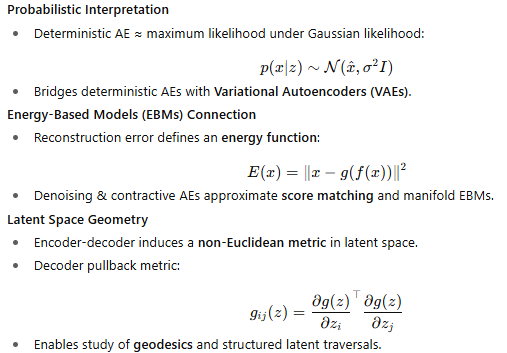